In [3]:
import pandas as pd
import numpy as np
import math

df = pd.read_pickle('electronika_clean.pkl')
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,1,2970,0,2970,Ника,Товары для дома,Хозтовары,Техника для дома/Техника для ухода за одеждой/...,9,90364
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,1,19490,0,19490,DeLonghi,Мелкая бытовая техника,Приготовление пищи,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,1,19990,0,19990,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,1,23680,0,23680,СМК,Мебель,Мягкая мебель,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,1,2420,0,2420,HP,Аксессуары,Картриджи и бумага,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,1,899,0,899,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17,38755
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,1,1090,0,1090,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,1,6859,0,6859,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17,140459
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,1,9120,0,9120,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956


In [4]:
actions_values = df['Actions'].value_counts().index
actions_set = set()
for action in actions_values:
    values = action.split(',')
    for value in values:
        actions_set.add(value)

for col in list(actions_set):
    df[col] = df['Actions'].apply(lambda x: int(str(x).find(col) != -1))
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,NomFullPath,Week,Nom_ID,СкидкаНаТоварПоПромоСлову,СкидкаДляСпособаОплаты,БесплатнаяДоставкаНаСуммуКорзины,НайдёшьДешевле,СкидкаСуммойПроцентомСЛимитом,СкидкаНаКомплект,Подарки
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,Техника для дома/Техника для ухода за одеждой/...,9,90364,0,0,0,0,0,0,0
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673,0,0,0,0,0,0,0
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757,0,0,1,0,0,0,0
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580,0,0,1,0,0,0,0
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,Техника для дома/Климатическая техника/Кондици...,17,38755,0,0,0,0,0,0,0
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908,0,0,0,0,0,0,0
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,Встраиваемая техника/Вытяжки/,17,140459,0,0,1,0,0,0,0
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956,0,0,0,0,0,0,0


In [5]:
clustering_2 = pd.read_csv('clustering_results_2.csv')
df_clustering_2 = df.join(clustering_2[['Phone_new', 'cluster']].set_index('Phone_new'), on='Phone_new')
df_clustering_2['cluster'].value_counts()

cluster
8     106327
0      42030
13     16376
12      6342
6       3030
9       2918
2       2868
5        968
7        950
1        663
4        361
10       167
3         51
11        21
Name: count, dtype: int64

In [6]:
df_clustering_2

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Week,Nom_ID,СкидкаНаТоварПоПромоСлову,СкидкаДляСпособаОплаты,БесплатнаяДоставкаНаСуммуКорзины,НайдёшьДешевле,СкидкаСуммойПроцентомСЛимитом,СкидкаНаКомплект,Подарки,cluster
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,9,90364,0,0,0,0,0,0,0,2
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,9,45673,0,0,0,0,0,0,0,2
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,10,120757,0,0,1,0,0,0,0,0
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,11,264580,0,0,1,0,0,0,0,0
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,9,76102,0,0,0,0,0,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,17,38755,0,0,0,0,0,0,0,8
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,17,31908,0,0,0,0,0,0,0,8
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,17,140459,0,0,1,0,0,0,0,8
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,17,295956,0,0,0,0,0,0,0,0


In [7]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')

## Крупная бытовая техника

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2165892939.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


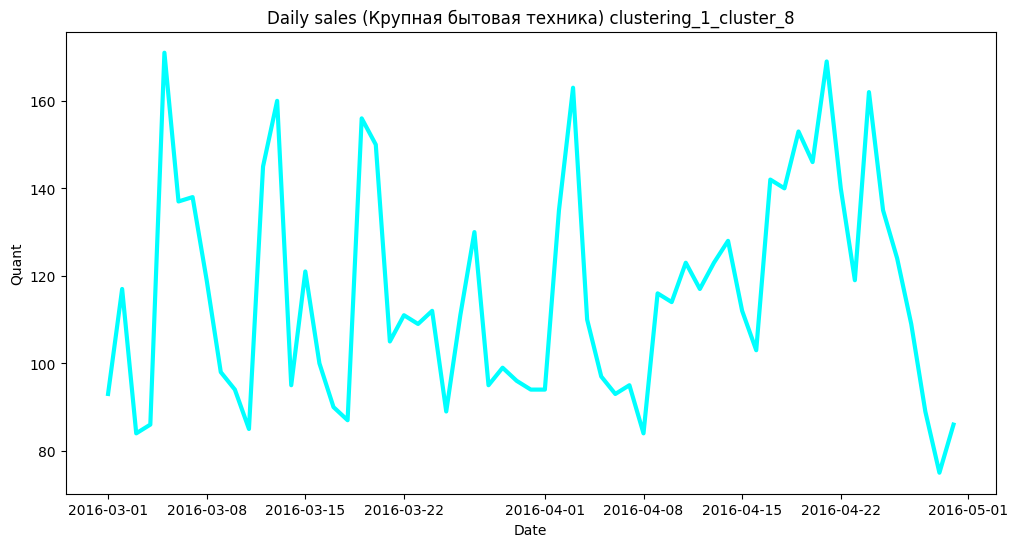

ADF Statistic: -2.89260759587015
p-value: 0.04621441145811646
Stationary


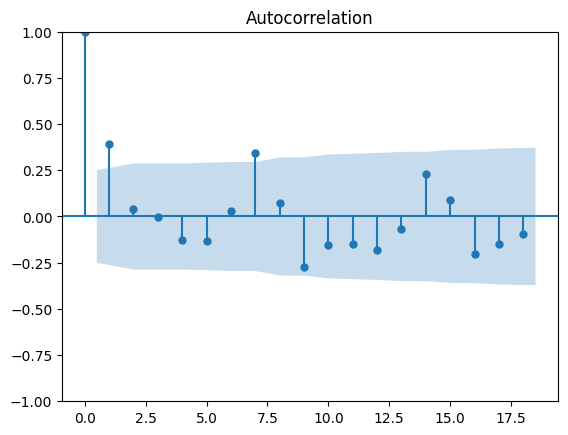

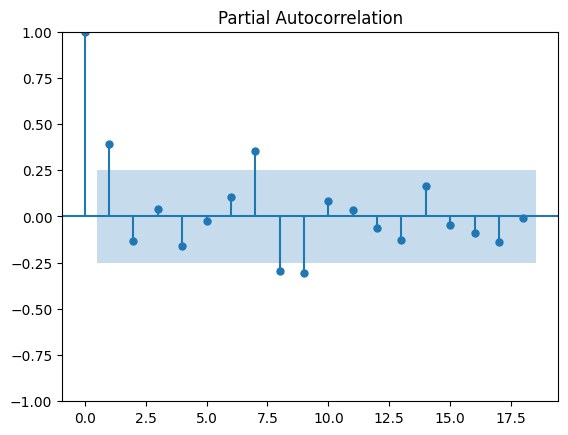

In [8]:
cluster = 8
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Крупная бытовая техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')

In [9]:
action_values.head(60)

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [10]:
demand_value = pd.read_csv('demand_indicator.csv')
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [11]:
# 0      25      50        75         100
# 0 1 2 | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 40 41 | 42 43 | 44 45   | 46 47    | 48

percent_0 = [0, 1, 2, 40, 41]
percent_25 = [3, 4, 5, 42, 43]
percent_50 = [6, 7, 8, 9, 44, 45]
percent_75 = [10, 11, 12, 46, 47]
percent_100 = [13, 48]

before_3_days = [37]
before_1_day = [38, 39]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]


In [12]:
action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 0.888159

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 0.874727

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 0.829640

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 1.017296

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 0.934448

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 1.054111

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 0.955380

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 1.083696

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 0.951479

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/516601297.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 0.888159
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,0.829640
2016-03-02,1.0,0.829640
2016-03-03,1.0,0.829640
2016-03-04,1.0,1.017296
2016-03-05,1.0,1.017296
...,...,...
2016-04-26,0.0,1.000000
2016-04-27,0.0,1.000000
2016-04-28,0.0,1.000000


In [13]:
action_values.head(60)

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,0.829640
2016-03-02,1.0,0.829640
2016-03-03,1.0,0.829640
2016-03-04,1.0,1.017296
2016-03-05,1.0,1.017296
2016-03-06,1.0,1.017296
2016-03-07,1.0,0.934448
2016-03-08,1.0,0.934448
2016-03-09,1.0,0.934448


In [14]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


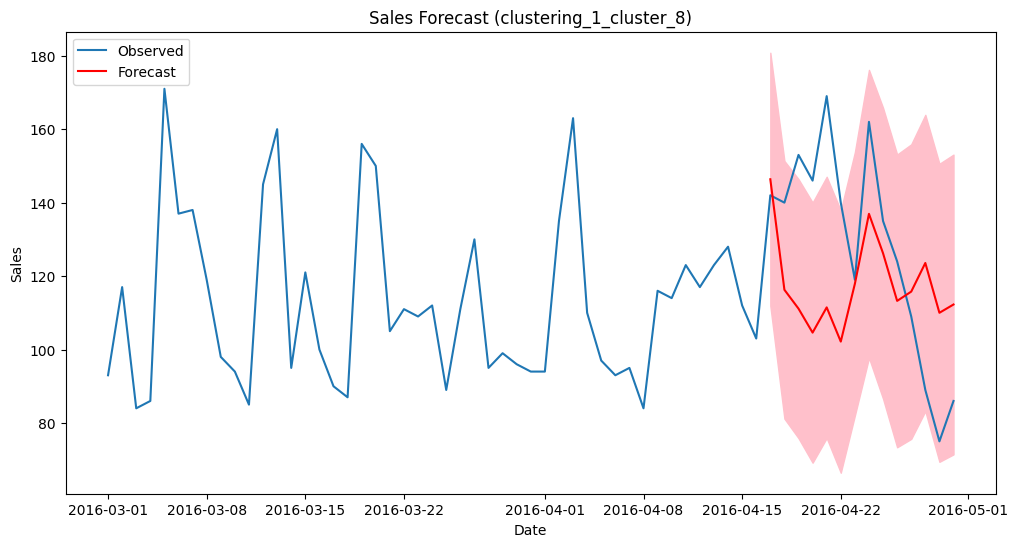

MAE: 25.35847647001855
MSE: 911.8191686229732
MAPE: 20.760354362121575


In [15]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2914320011.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


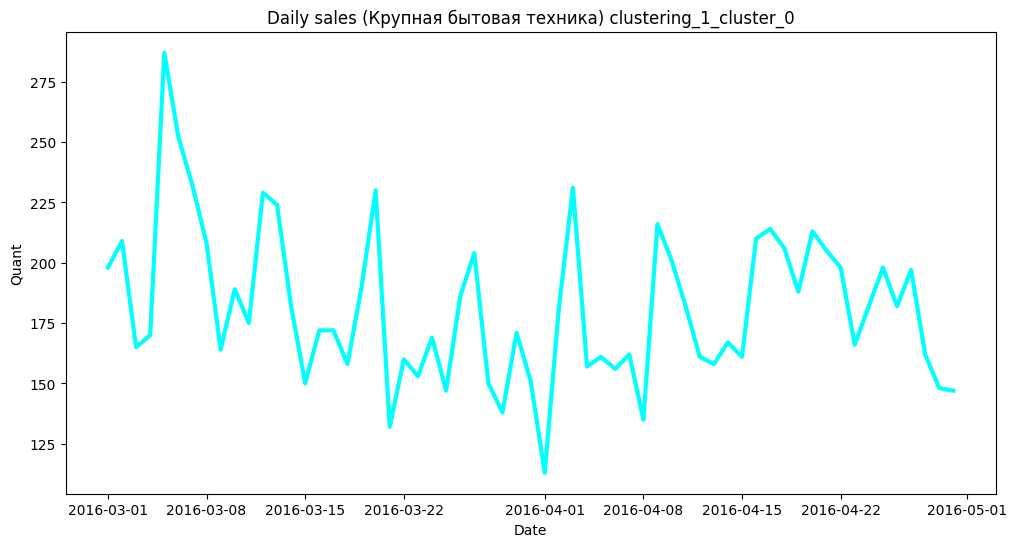

ADF Statistic: -1.9851754293651185
p-value: 0.29311074487281974
Non-Stationary


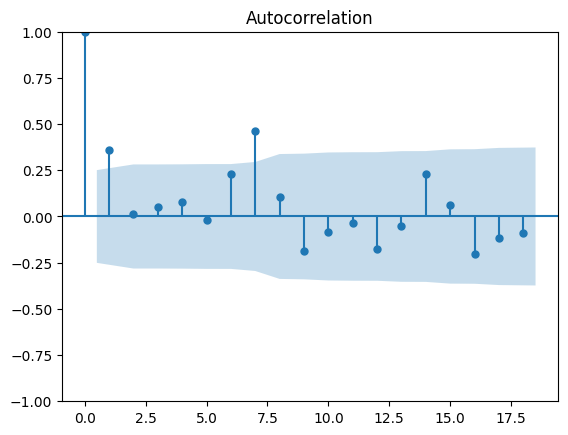

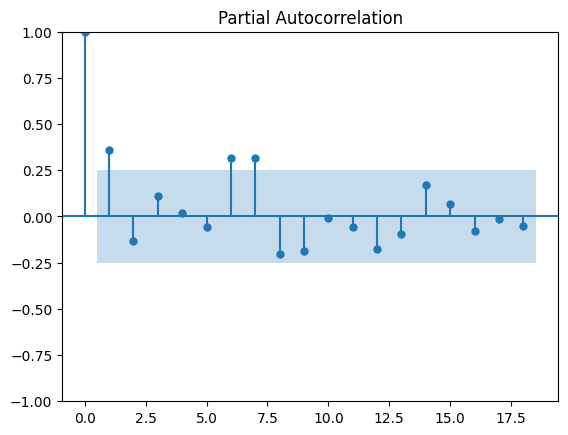

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [16]:
cluster = 0
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Крупная бытовая техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')
action_values.head(60)

In [17]:
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [18]:
# 0      25      50        75         100
# 0 1 2 | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 40 41 | 42 43 | 44 45   | 46 47    | 48

percent_0 = [0, 1, 2, 40, 41]
percent_25 = [3, 4, 5, 42, 43]
percent_50 = [6, 7, 8, 9, 44, 45]
percent_75 = [10, 11, 12, 46, 47]
percent_100 = [13, 48]

before_3_days = [37]
before_1_day = [38, 39]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]

action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 1.006840

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 0.972726

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 1.144628

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 1.169201

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 1.001342

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 1.049438

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 1.129526

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 1.022963

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 1.032538

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2683469030.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 1.006840
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,1.144628
2016-03-02,1.0,1.144628
2016-03-03,1.0,1.144628
2016-03-04,1.0,1.169201
2016-03-05,1.0,1.169201
...,...,...
2016-04-26,0.0,1.000000
2016-04-27,0.0,1.000000
2016-04-28,0.0,1.000000


In [19]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


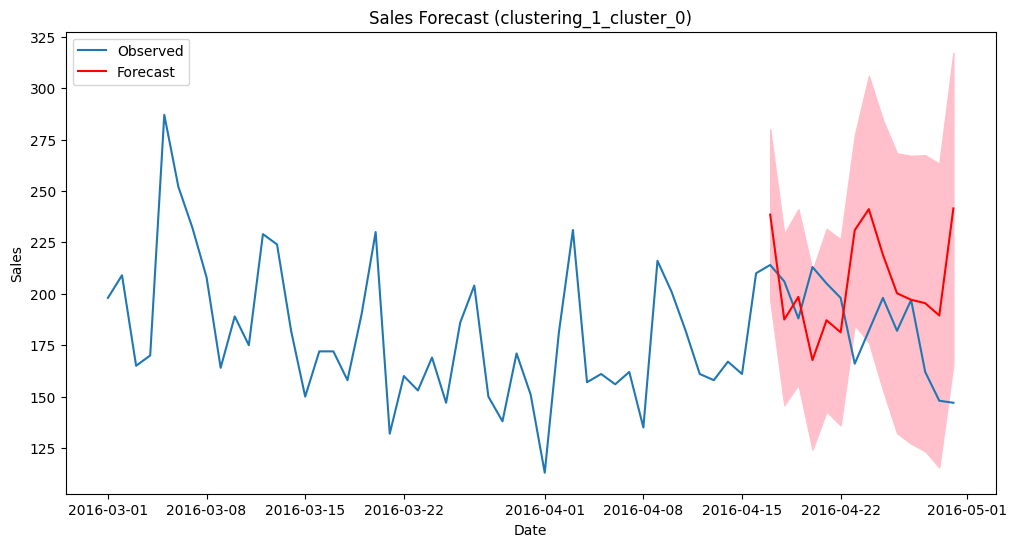

MAE: 33.29082994260329
MSE: 1710.5188828906555
MAPE: 19.25720745213387


In [20]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# Мелкая бытовая техника

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/569285318.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


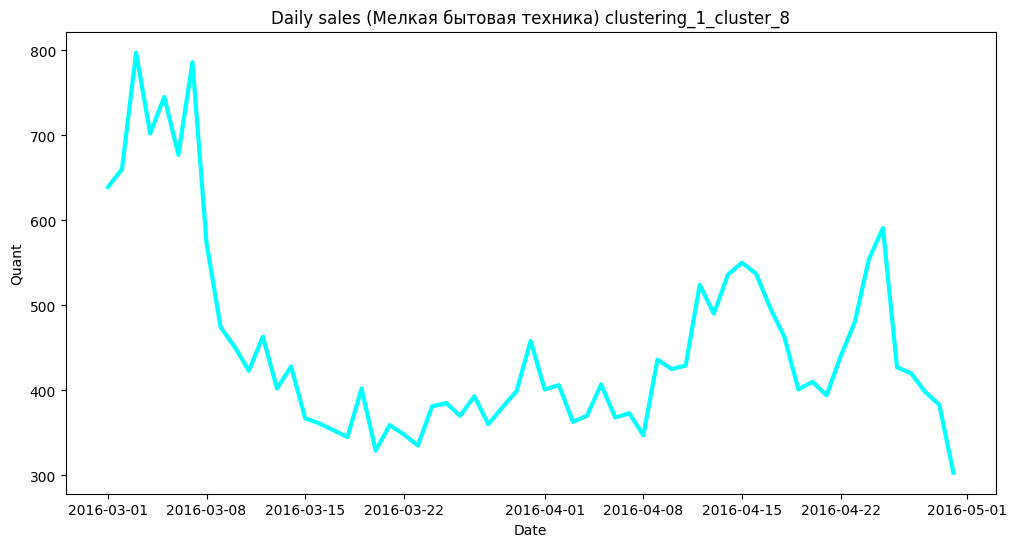

ADF Statistic: -2.1755293263821285
p-value: 0.21524645773753975
Non-Stationary


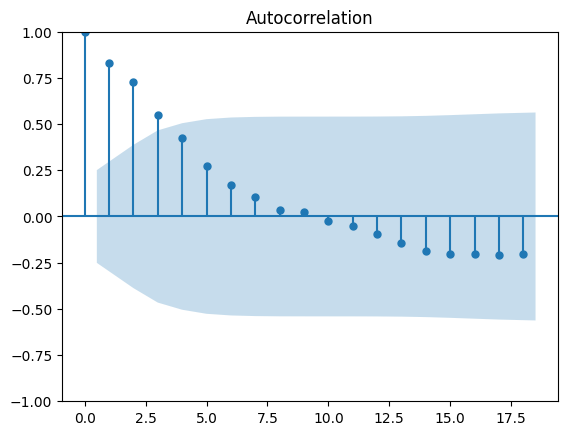

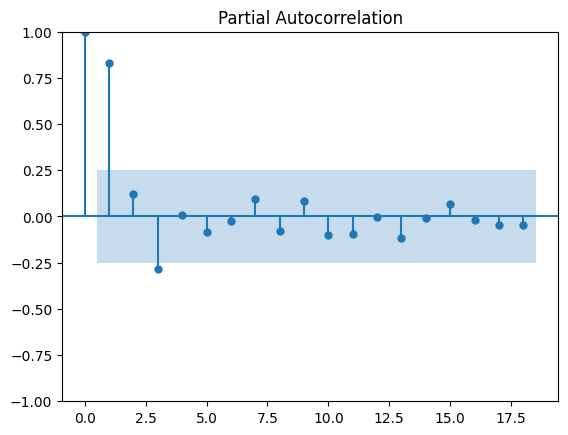

In [21]:
cluster = 8
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Мелкая бытовая техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')

In [22]:
action_values.head(60)

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [23]:
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [24]:
# 0      25      50        75         100
# 0 1 2  | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 39 40 41 | 42 43 | 44 45   | 46 47    | 48
# 52 53 | 54 55 | 56 57 |  58           |59

percent_0 = [0, 1, 2, 40, 41, 52, 53]
percent_25 = [3, 4, 5, 42, 43, 54, 55]
percent_50 = [6, 7, 8, 9, 44, 45, 56, 57]
percent_75 = [10, 11, 12, 46, 47, 58, 59]
percent_100 = [13, 48, 60]

before_3_days = [36, 49]
before_1_day = [37, 38, 50, 51]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]

action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 2.024475

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 1.336011

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 1.172489

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 1.167478

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 1.141658

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 1.087000

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 1.062188

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 1.008123

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 0.926007

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2841394520.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 2.024475
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,1.172489
2016-03-02,1.0,1.172489
2016-03-03,1.0,1.172489
2016-03-04,1.0,1.167478
2016-03-05,1.0,1.167478
...,...,...
2016-04-26,1.0,1.141658
2016-04-27,1.0,1.141658
2016-04-28,1.0,1.087000


In [25]:
p, d, q = 2, 1, 1
P, D, Q, s = 2, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

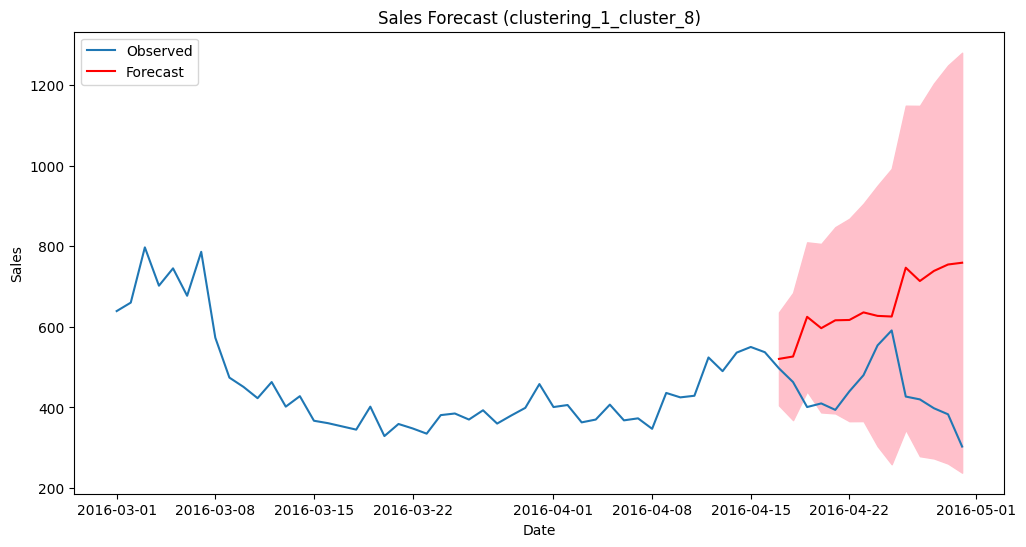

MAE: 210.0642227359301
MSE: 60797.5220439669
MAPE: 53.25774448181871


In [26]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/1005153897.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


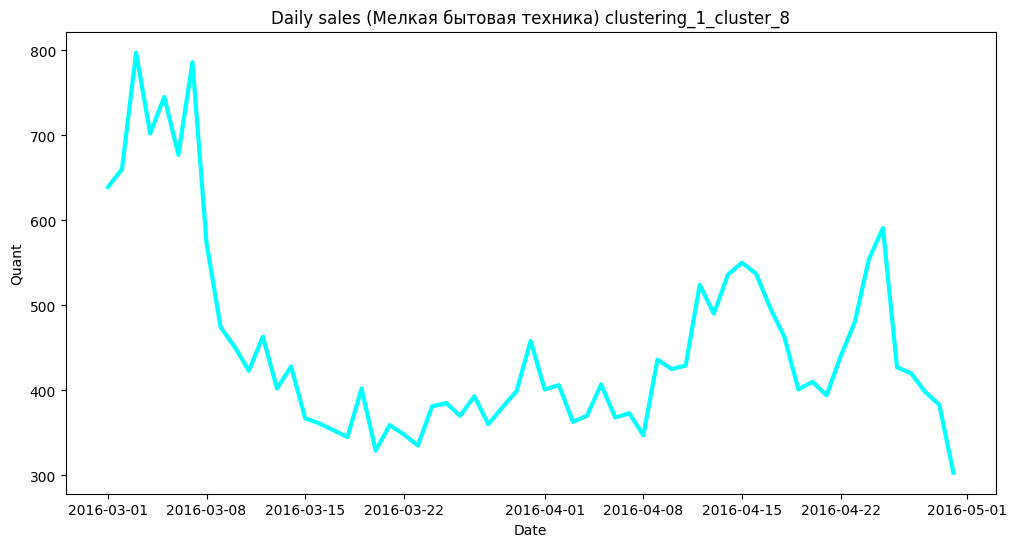

ADF Statistic: -2.1755293263821285
p-value: 0.21524645773753975
Non-Stationary


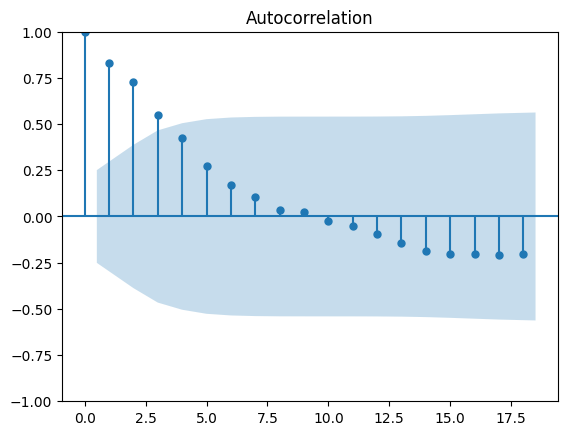

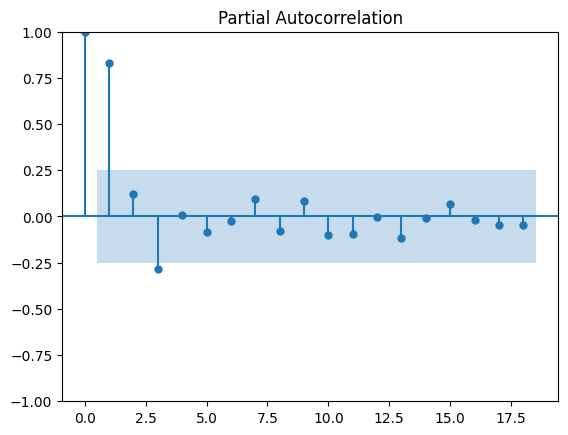

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [27]:
cluster = 8
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Мелкая бытовая техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')
action_values.head(60)

In [28]:
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [29]:
# 0      25      50        75         100
# 0 1 2  | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 39 40 41 | 42 43 | 44 45   | 46 47    | 48
# 52 53 | 54 55 | 56 57 |  58           |59

percent_0 = [0, 1, 2, 40, 41, 52, 53]
percent_25 = [3, 4, 5, 42, 43, 54, 55]
percent_50 = [6, 7, 8, 9, 44, 45, 56, 57]
percent_75 = [10, 11, 12, 46, 47, 58, 59]
percent_100 = [13, 48, 60]

before_3_days = [36, 49]
before_1_day = [37, 38, 50, 51]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]

action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 2.192478

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 0.995061

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 0.958755

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 0.951415

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 0.789451

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 0.825649

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 0.528263

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 0.825726

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 1.027149

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2542467309.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 2.192478
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,0.958755
2016-03-02,1.0,0.958755
2016-03-03,1.0,0.958755
2016-03-04,1.0,0.951415
2016-03-05,1.0,0.951415
...,...,...
2016-04-26,1.0,0.789451
2016-04-27,1.0,0.789451
2016-04-28,1.0,0.825649


In [30]:
p, d, q = 2, 1, 1
P, D, Q, s = 2, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

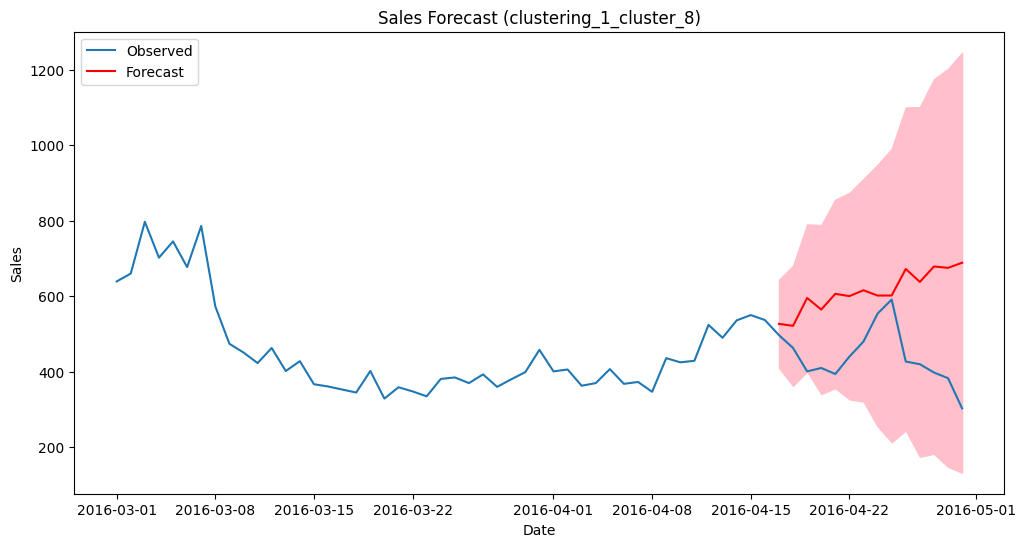

MAE: 173.25578361289567
MSE: 41278.001100939684
MAPE: 44.08478005979229


In [31]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# Цифровая техника

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2701435180.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


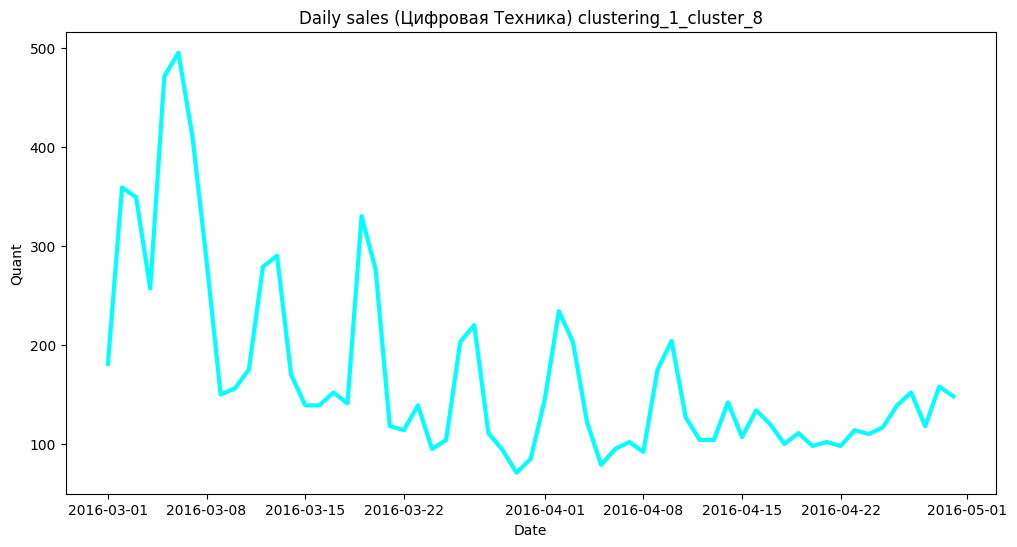

ADF Statistic: -6.186964719184965
p-value: 6.255354181692934e-08
Stationary


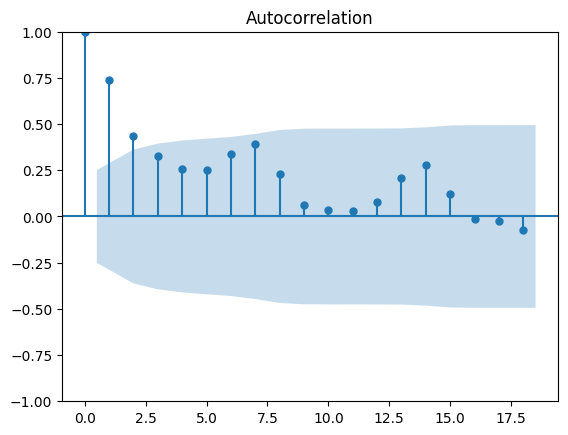

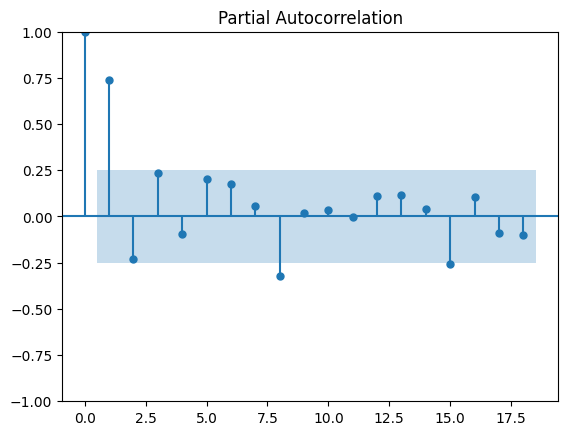

In [32]:
cluster = 8
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Цифровая Техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')

In [33]:
action_values.head(60)

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [34]:
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [35]:
# 0      25      50        75         100
# 0 1 2 | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 40 41 | 42 43 | 44 45   | 46 47    | 48

percent_0 = [0, 1, 2, 40, 41]
percent_25 = [3, 4, 5, 42, 43]
percent_50 = [6, 7, 8, 9, 44, 45]
percent_75 = [10, 11, 12, 46, 47]
percent_100 = [13, 48]

before_3_days = [37]
before_1_day = [38, 39]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]

action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 0.740072

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 0.781491

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 1.139900

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 1.529720	

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 0.878496

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 1.236866	

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 0.969485	

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 0.819405

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 0.846165

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/1387028318.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 0.740072
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,1.13990
2016-03-02,1.0,1.13990
2016-03-03,1.0,1.13990
2016-03-04,1.0,1.52972
2016-03-05,1.0,1.52972
...,...,...
2016-04-26,0.0,1.00000
2016-04-27,0.0,1.00000
2016-04-28,0.0,1.00000


In [36]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


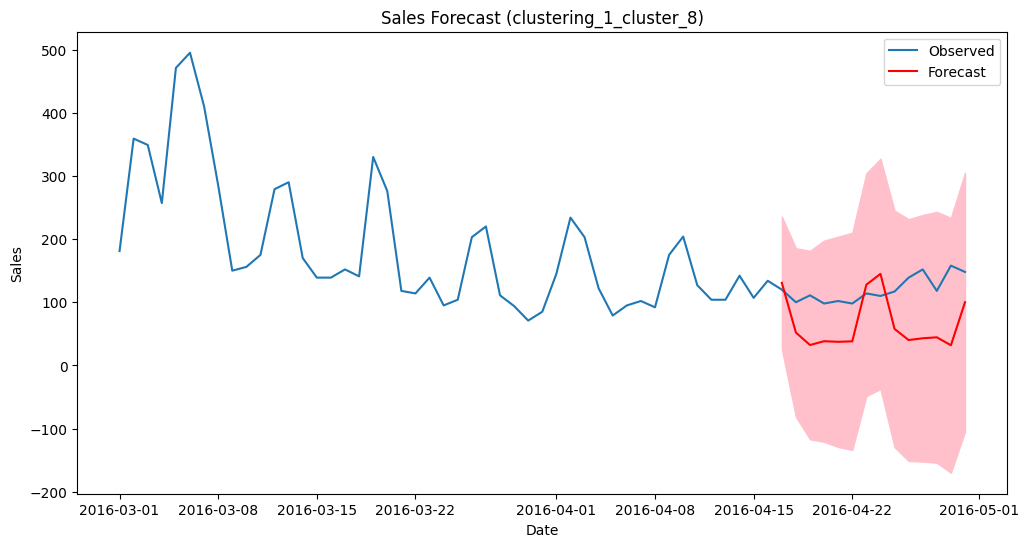

MAE: 63.19254864444109
MSE: 5004.343712811999
MAPE: 51.7678529670342


In [37]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/1087264258.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\


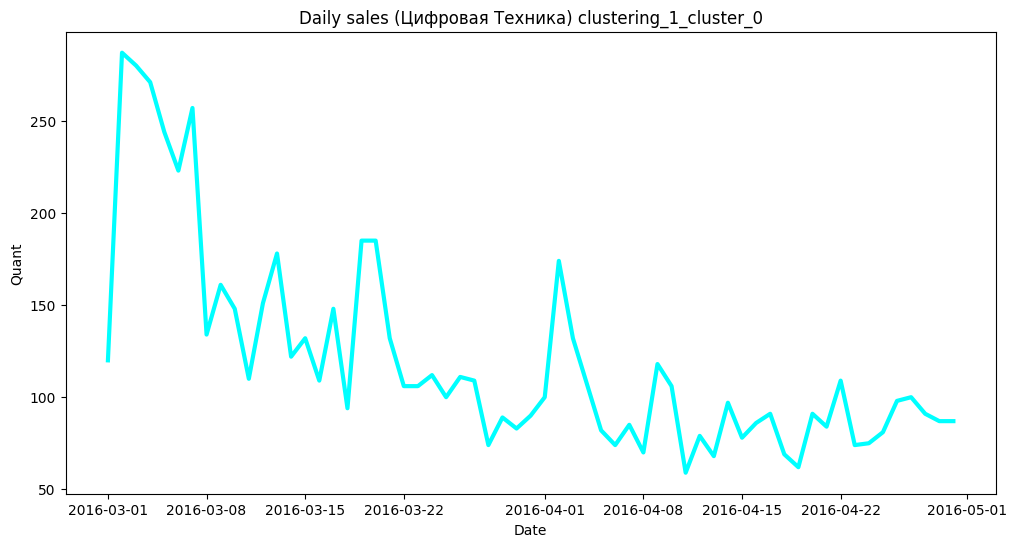

ADF Statistic: -2.199038663599769
p-value: 0.2065945515192243
Non-Stationary


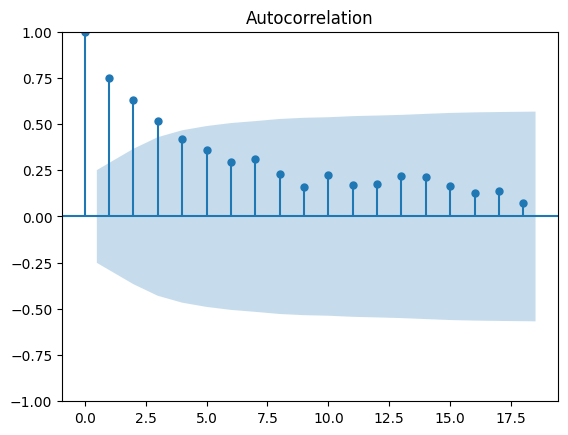

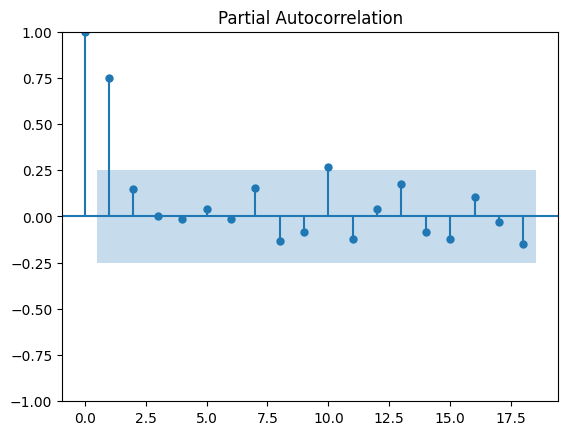

In [38]:
cluster = 0
action_name = 'СкидкаСуммойПроцентомСЛимитом'
category_name = 'Цифровая Техника'

daily_sales = df_clustering_2[df_clustering_2['cluster'] == cluster][df_clustering_2['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Quant'], linewidth=3,c='cyan')
plt.title(f"Daily sales ({category_name}) clustering_1_cluster_{cluster}")
plt.xlabel("Date")
plt.ylabel("Quant")
plt.show()

check_stationarity(daily_sales['Quant'])

plot_acf(daily_sales)
plot_pacf(daily_sales)
plt.show()

stat = pd.DataFrame()
category1 = df_clustering_2[df_clustering_2['TN'] == f'{category_name}']
stat['OrderDate'] = category1['OrderDate']
stat['Quant'] = category1[f'{action_name}'] * category1['Quant']
stat = stat.groupby('OrderDate').sum()

action_active = pd.DataFrame(index=stat[stat['Quant'] > 10].index)
action_active['Action'] = 1

action_values = pd.DataFrame(index=stat.index).join(action_active, how='left')
action_values = action_values.fillna(0).reset_index().sort_values(by='OrderDate').set_index('OrderDate')

In [39]:
action_values.head(60)

,Action
OrderDate,
2016-03-01,1.0
2016-03-02,1.0
2016-03-03,1.0
2016-03-04,1.0
2016-03-05,1.0
2016-03-06,1.0
2016-03-07,1.0
2016-03-08,1.0
2016-03-09,1.0


In [40]:
demand_value

,Unnamed: 0,category,before_3,before_1,0_percent,25_percent,50_percent,75_percent,100_percent,after_1,after_3,cluster
0,0,Крупная бытовая техника,1.006840,0.972726,1.144628,1.169201,1.001342,1.049438,1.129526,1.022963,1.032538,0
1,1,Мелкая бытовая техника,2.192478,0.995061,0.958755,0.951415,0.789451,0.825649,0.528263,0.825726,1.027149,0
2,2,Цифровая Техника,0.779614,0.823316,1.075064,1.129220,1.139153,1.107040,1.001811,0.957288,1.065655,0
3,3,Крупная бытовая техника,0.888159,0.874727,0.829640,1.017296,0.934448,1.054111,0.955380,1.083696,0.951479,8
4,4,Мелкая бытовая техника,2.024475,1.336011,1.172489,1.167478,1.141658,1.087000,1.062188,1.008123,0.926007,8
5,5,Цифровая Техника,0.740072,0.781491,1.139900,1.529720,0.878496,1.236866,0.969485,0.819405,0.846165,8


In [42]:
# 0      25      50        75         100
# 0 1 2 | 3 4 5 | 6 7 8 9 | 10 11 12 | 13
# 40 41 | 42 43 | 44 45   | 46 47    | 48

percent_0 = [0, 1, 2, 40, 41]
percent_25 = [3, 4, 5, 42, 43]
percent_50 = [6, 7, 8, 9, 44, 45]
percent_75 = [10, 11, 12, 46, 47]
percent_100 = [13, 48]

before_3_days = [37]
before_1_day = [38, 39]
after_1_day = [14, 49]
after_3_days = [50, 51, 15, 16]

action_values['action_indicator'] = 1

for i in before_3_days:
    action_values['action_indicator'].iloc[i] = 0.779614	

for i in before_1_day:
    action_values['action_indicator'].iloc[i] = 0.823316	

for i in percent_0:
    action_values['action_indicator'].iloc[i] = 1.075064		

for i in percent_25:
    action_values['action_indicator'].iloc[i] = 1.129220

for i in percent_50:
    action_values['action_indicator'].iloc[i] = 1.139153	

for i in percent_75:
    action_values['action_indicator'].iloc[i] = 1.107040	

for i in percent_100:
    action_values['action_indicator'].iloc[i] = 1.001811	

for i in after_1_day:
    action_values['action_indicator'].iloc[i] = 0.957288

for i in after_3_days:
    action_values['action_indicator'].iloc[i] = 1.065655

action_values

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_48399/2449821316.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  action_values['action_indicator'].iloc[i] = 0.779614
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_

,Action,action_indicator
OrderDate,,
2016-03-01,1.0,1.075064
2016-03-02,1.0,1.075064
2016-03-03,1.0,1.075064
2016-03-04,1.0,1.129220
2016-03-05,1.0,1.129220
...,...,...
2016-04-26,0.0,1.000000
2016-04-27,0.0,1.000000
2016-04-28,0.0,1.000000


In [43]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7

model = SARIMAX(daily_sales.iloc[:-14], exog=action_values['action_indicator'][:-14], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model

/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/timurratnikov/diplom_electronice/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


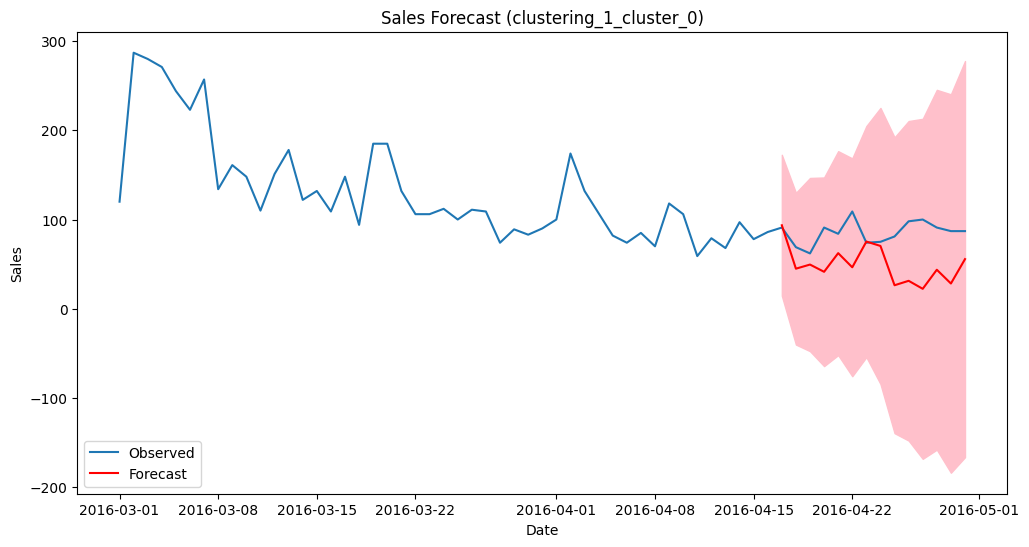

MAE: 36.81913691504563
MSE: 1983.0852628240425
MAPE: 40.88667952430781


In [44]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods, exog=action_values['action_indicator'][-14:])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title(f"Sales Forecast (clustering_1_cluster_{cluster})")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
mape = mean_absolute_percentage_error(observed, forecast_mean) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')